# Code Demonstration for Group Project

## Necessary imports

In [1]:
# Necessary imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Libraries for Multicollinearity and Factor Analysis checks
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Step 1: Data Loading and Processing

In [2]:
from utils import PanelDataProcessor as PDP

In [3]:
processor = PDP(
    wb_path='../data/WorldBank.csv', 
    owid_path='../data/OWID.csv'
)

final_df = processor.run_pipeline(output_filename='Merged_Sustainable_Energy_Panel.csv')

Cleaning World Bank dataset...
World Bank dataset cleaned. Shape: (3990, 11)
Cleaning OWID dataset...
OWID dataset cleaned. Shape: (17134, 130)
Merging datasets into a panel...
Panel dataset successfully created! Shape: (18291, 138)
Data saved to Merged_Sustainable_Energy_Panel.csv


## Step 2: Data Cleaning

In [4]:
from utils import PanelDataCleaner as PDC

In [5]:
cleaner = PDC(input_filepath='Merged_Sustainable_Energy_Panel.csv')

final_clean_df = cleaner.run_cleaning_pipeline(
        start_year=2012, 
        end_year=2021, 
        output_filename='Cleaned_Analysis_Ready_Panel.csv'
    )

Loading data from Merged_Sustainable_Energy_Panel.csv...
Filtering dataset for years 2012 to 2021...
Trimming variables...
Imputing missing values...
Data successfully saved to Cleaned_Analysis_Ready_Panel.csv
Final dataset shape: (2600, 18)


/Users/amyqian/Documents/GitHub/ISEG_ProgrammingForDataScience/Project/code/utils.py:143: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(input_filepath)


## Step 3: Data Exploration and Checks

In [6]:
from utils import DataExploration as DE

Initialized DataExploration with 760 valid records and 15 numeric variables.

--- Calculating Descriptive Statistics ---
Saved to Descriptive_Statistics.csv
                                    mean      min           max          std
renewable_energy_share_pct         17.99     0.00  8.290000e+01        16.09
access_to_clean_cooking_pct        92.78    14.50  1.000000e+02        16.37
land_area_sq_km               1268678.94   706.00  1.637687e+07   2769115.72
gdp_per_capita               12537221.86   492.63  8.162911e+08  88530634.32
fossil_electricity                206.58     0.00  5.677960e+03       624.90
nuclear_electricity                33.40     0.00  8.094100e+02       108.15
energy_per_capita               44586.63  1902.54  2.452950e+05     41888.67
co2_emissions_per_capita            8.04     0.45  5.360000e+01         7.14
access_to_electricity_pct          98.91    61.50  1.000000e+02         3.73
gdp_growth_pct                      2.37   -30.00  2.462000e+01         4

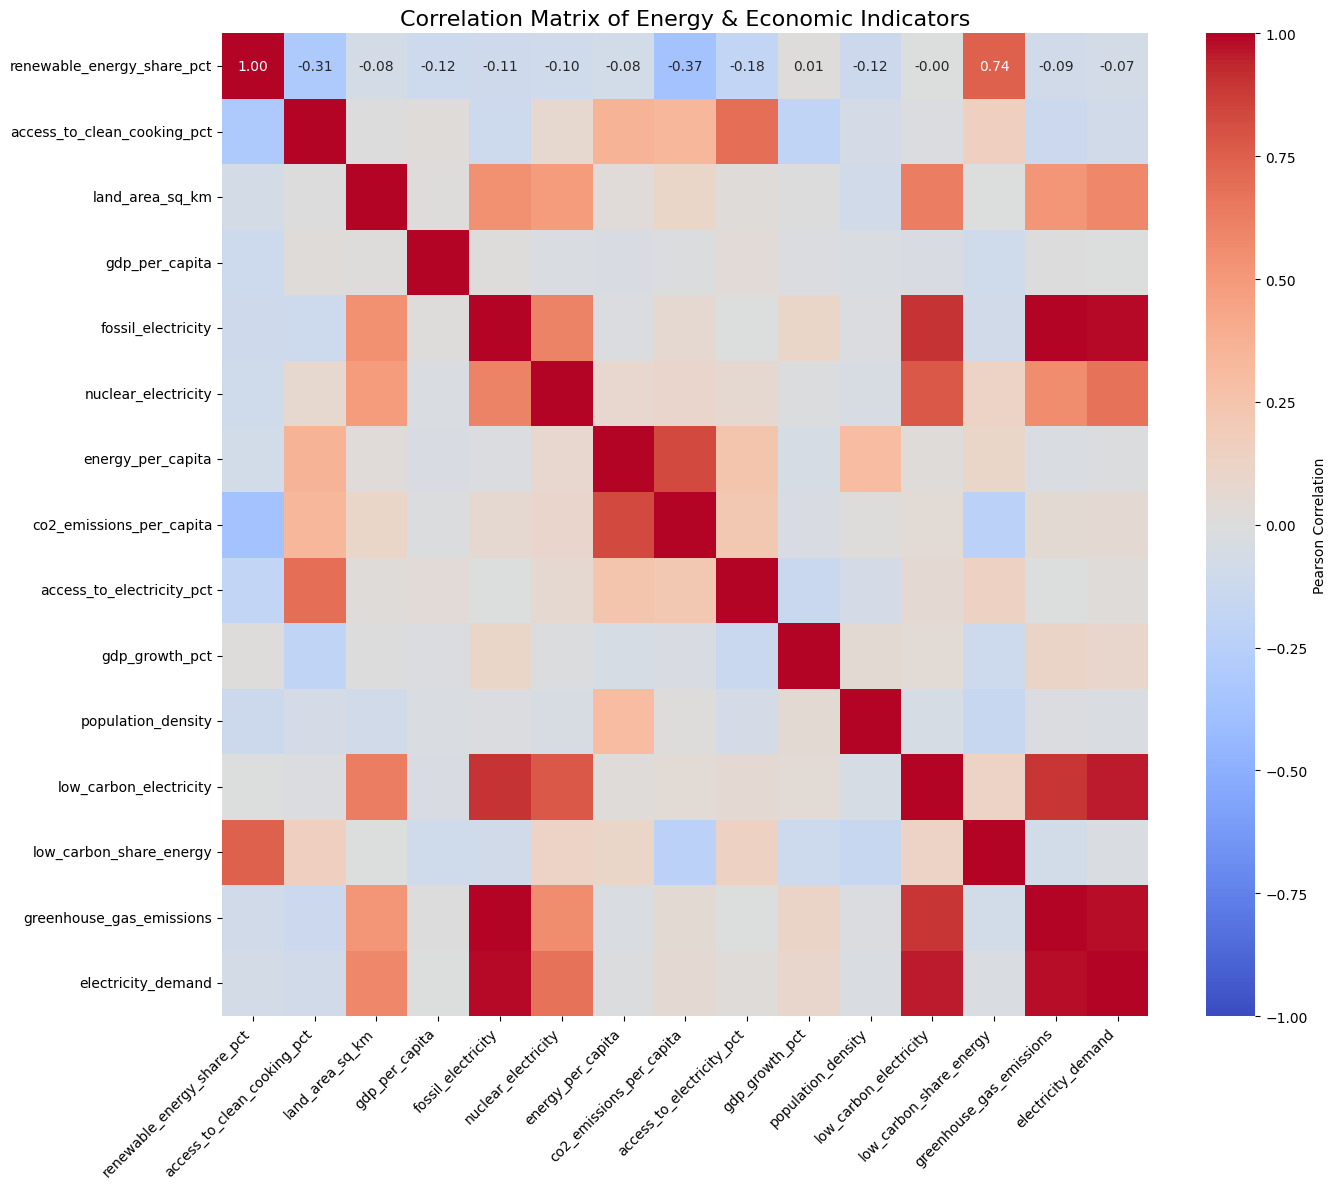

Heatmap saved to correlation_heatmap.png

--- Checking Multicollinearity (VIF) ---
Variables with VIF > 10 (Consider dropping/transforming these):
                   Variable         VIF
         electricity_demand 6540.638115
         fossil_electricity 4475.755767
     low_carbon_electricity  706.570949
   greenhouse_gas_emissions  353.682686
  access_to_electricity_pct  110.599454
access_to_clean_cooking_pct   98.560417
          energy_per_capita   26.137739
   co2_emissions_per_capita   25.972928
    low_carbon_share_energy   12.780547
 renewable_energy_share_pct   11.340103

--- Checking Factor Analysis Prerequisites ---
Bartlett's Test P-value: 0.0
  -> SUCCESS: Variables are correlated enough for Factor Analysis.

Overall KMO Score: 0.560
  -> WARNING: KMO score is too low. You may need to drop variables with low individual KMOs.

Variables with the lowest KMO scores (< 0.50 should be dropped):
                   Variable      KMO
         population_density 0.108146
          

/opt/anaconda3/lib/python3.11/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [7]:
# 1. Load your newly cleaned dataset
cleaned_df = pd.read_csv('Cleaned_Analysis_Ready_Panel.csv')
    
# 2. Initialize the Data Exploration class
explorer = DE(cleaned_df)
    
# 3. Run all analyses
explorer.run_all()

In [8]:
from utils import AdvancedDataProcessing as ADP

Initialized with 14 independent variables.

--- Handling Outliers (Capping at 1.0th and 99.0th percentiles) ---
Outliers capped successfully.

--- Handling Skewed Distributions (Threshold: |Skew| > 1.5) ---
Highly skewed variables detected: ['access_to_clean_cooking_pct', 'land_area_sq_km', 'gdp_per_capita', 'fossil_electricity', 'nuclear_electricity', 'energy_per_capita', 'co2_emissions_per_capita', 'access_to_electricity_pct', 'population_density', 'low_carbon_electricity', 'low_carbon_share_energy', 'greenhouse_gas_emissions', 'electricity_demand']
Log transformations applied to skewed variables.

--- Dropping Highly Correlated Variables (Threshold: 0.8) ---
Variables dropped due to correlation > 0.8: ['co2_emissions_per_capita', 'greenhouse_gas_emissions', 'electricity_demand']
Remaining variables: ['access_to_clean_cooking_pct', 'land_area_sq_km', 'gdp_per_capita', 'fossil_electricity', 'nuclear_electricity', 'energy_per_capita', 'access_to_electricity_pct', 'gdp_growth_pct', 'pop

/Users/amyqian/Documents/GitHub/ISEG_ProgrammingForDataScience/Project/code/utils.py:398: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.X[col] = self.X[col].clip(lower=lower_bound, upper=upper_bound)
/Users/amyqian/Documents/GitHub/ISEG_ProgrammingForDataScience/Project/code/utils.py:398: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.X[col] = self.X[col].clip(lower=lower_bound, upper=upper_bound)
/Users/amyqian/Documents/GitHub/ISEG_ProgrammingForDataScience/Project/code/utils.py:398: SettingWithC

Heatmap saved as 'reduced_correlation_heatmap.png'.

--- Re-checking Multicollinearity (VIF) ---
                   Variable       VIF
            land_area_sq_km 55.080859
     low_carbon_electricity 51.572476
         population_density 28.323104
    low_carbon_share_energy 27.660276
         fossil_electricity 11.387633
          energy_per_capita  9.644437
access_to_clean_cooking_pct  2.899489
        nuclear_electricity  2.640206
  access_to_electricity_pct  2.025497
             gdp_per_capita  1.093407
             gdp_growth_pct  1.071357

--- Testing Factor Analysis Readiness ---
Bartlett's Test P-value: 0.0
  -> SUCCESS: Variables are correlated enough for Factor Analysis.
Overall KMO Score: 0.373
  -> WARNING: KMO score is below 0.60. Factor Analysis might not yield distinct groups.


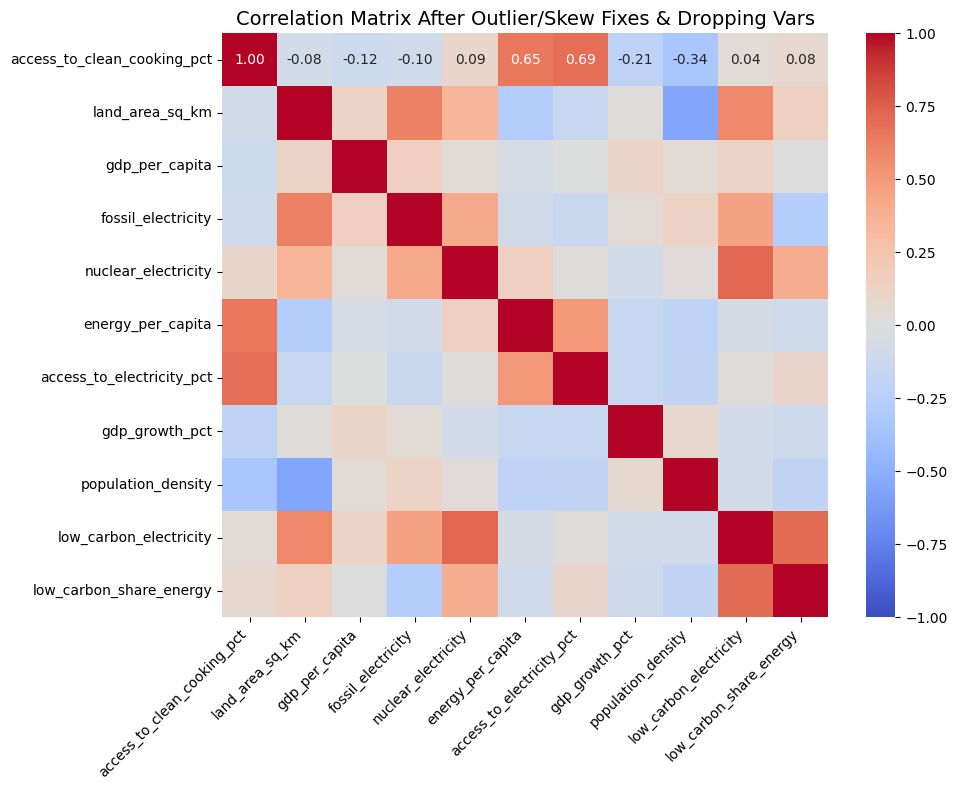

In [9]:
# 1. Load the previously cleaned data
df_clean = pd.read_csv('Cleaned_Analysis_Ready_Panel.csv')
    
# 2. Initialize processing class
processor = ADP(dataframe=df_clean, target_variable='renewable_energy_share_pct')
    
# 3. Run the complete pipeline
X_final, y_final = processor.run_pipeline()

# Optional: save X_final and y_final for your Factor Analysis
# X_final.to_csv('Factor_Analysis_Ready_X.csv', index=False)

In [10]:
from utils import FactorAnalysisPrep

In [11]:
# 1. Load the data
df_clean = pd.read_csv('Cleaned_Analysis_Ready_Panel.csv')

# 2. Initialize the prep class
prep = FactorAnalysisPrep(dataframe=df_clean, target_variable='renewable_energy_share_pct')

# 3. RUN IT ALL IN ONE LINE!
X_for_FA, y_for_Model = prep.run_pipeline()

# Optional: Save it so you don't have to run it again
# X_for_FA.to_csv('Factor_Analysis_Ready_X.csv', index=False)

Initialized with 6 highly curated features.

--- Handling Outliers ---
Outliers capped successfully.

--- Handling Skewed Distributions ---
Log transformed skewed variables: ['access_to_electricity_pct', 'access_to_clean_cooking_pct', 'gdp_per_capita', 'energy_per_capita', 'low_carbon_share_energy']

--- Standardizing Variables ---
Data standardization complete.

--- Final VIF Check ---
                   Variable      VIF
access_to_clean_cooking_pct 2.624725
  access_to_electricity_pct 1.963460
          energy_per_capita 1.852127
             gdp_growth_pct 1.069477
    low_carbon_share_energy 1.067504
             gdp_per_capita 1.036422

--- Factor Analysis Prerequisites ---
Bartlett's Test P-value: 2.7163367495541405e-210
  -> SUCCESS: Variables are correlated enough for Factor Analysis.
Overall KMO Score: 0.665
  -> SUCCESS: KMO score is adequate for Factor Analysis.

Individual KMO Scores (>0.5 is good):
                   Variable  Individual_KMO
    low_carbon_share_energy    

## Step 4: Factor Analysis and Clustering

In [12]:
from utils import CountryProfiler


--- Step 1: Factor Analysis ---
Optimal number of latent factors found (Eigenvalue > 1): 3

Factor Loadings (What each factor represents):
                             Factor_1  Factor_2  Factor_3
access_to_electricity_pct        0.74      0.09      0.01
access_to_clean_cooking_pct      0.93      0.06     -0.14
gdp_per_capita                  -0.02      0.02      0.70
gdp_growth_pct                  -0.20     -0.10      0.17
energy_per_capita                0.70     -0.11     -0.05
low_carbon_share_energy          0.02      1.00     -0.02

--- Step 2: Determining Optimal Clusters ---
Cluster optimization plot saved as 'Cluster_Optimization.png'.
Recommended number of clusters (Max Silhouette Score): 2

--- Step 3: Fitting K-Means (K=2) ---

Median Characteristics of Each Profile (Unscaled Values):
                 access_to_electricity_pct  access_to_clean_cooking_pct  \
Profile_Cluster                                                           
0                                    100

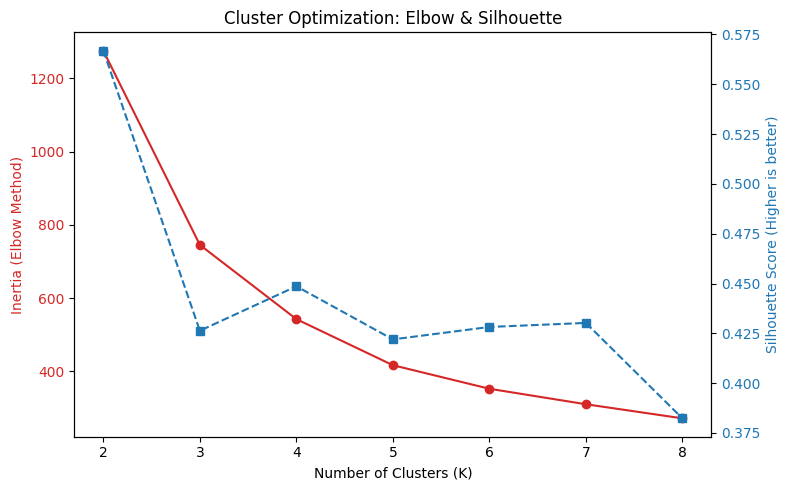

In [13]:
# Ensure X_for_FA and df_clean are loaded from your previous Data Prep script
# df_clean = pd.read_csv('Cleaned_Analysis_Ready_Panel.csv')

profiler = CountryProfiler(X_scaled=X_for_FA, original_df=df_clean)

# Run the pipeline
final_panel_with_profiles = profiler.run_profiling()

# Save the finalized dataset!
final_panel_with_profiles.to_csv("Final_Panel_With_Profiles.csv", index=False)